In [84]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import importlib
import EDA as eda 
import Feature_eng as feng
importlib.reload(eda)
importlib.reload(feng)



<module 'Feature_eng' from 'c:\\Users\\Alexander  Hassfjell\\Documents\\Usyd\\Machine learning in buisness analytics\\ML project\\QBUS3820-Group-Assignment\\Feature_eng.py'>

In [79]:
import warnings
warnings.filterwarnings('ignore') 

# Plot settings
sns.set_context('notebook') # optimises figures for notebook display
sns.set_style('ticks') # set default plot style
colours = ['#4E79A7','#F28E2C','#E15759','#76B7B2','#59A14F', 
          '#EDC949','#AF7AA1','#FF9DA7','#9C755F','#BAB0AB']
sns.set_palette(colours) # set custom color scheme


%matplotlib inline
plt.rcParams['figure.figsize'] = (9, 6)
plt.rcParams['figure.dpi'] = 80
%config InlineBackend.figure_format = 'retina'

In [80]:
transactions, demographics, products, campaigns, campaign_descriptions, promotions = eda.retrieve_data()

### Define Churn variable

In [81]:
churn, churn_train, churn_valid, churn_test = feng.churn(transactions, threshold_days=21)
print(churn.head())
print(churn.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1469307 entries, 0 to 1469306
Data columns (total 12 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   household_id           1469307 non-null  int64         
 1   store_id               1469307 non-null  int64         
 2   basket_id              1469307 non-null  int64         
 3   product_id             1469307 non-null  int64         
 4   quantity               1469307 non-null  int64         
 5   sales_value            1469307 non-null  float64       
 6   retail_disc            1469307 non-null  float64       
 7   coupon_disc            1469307 non-null  float64       
 8   coupon_match_disc      1469307 non-null  float64       
 9   week                   1469307 non-null  int64         
 10  transaction_timestamp  1469307 non-null  datetime64[ns]
 11  transaction_datetime   1469307 non-null  datetime64[ns]
dtypes: datetime64[ns](2), float6

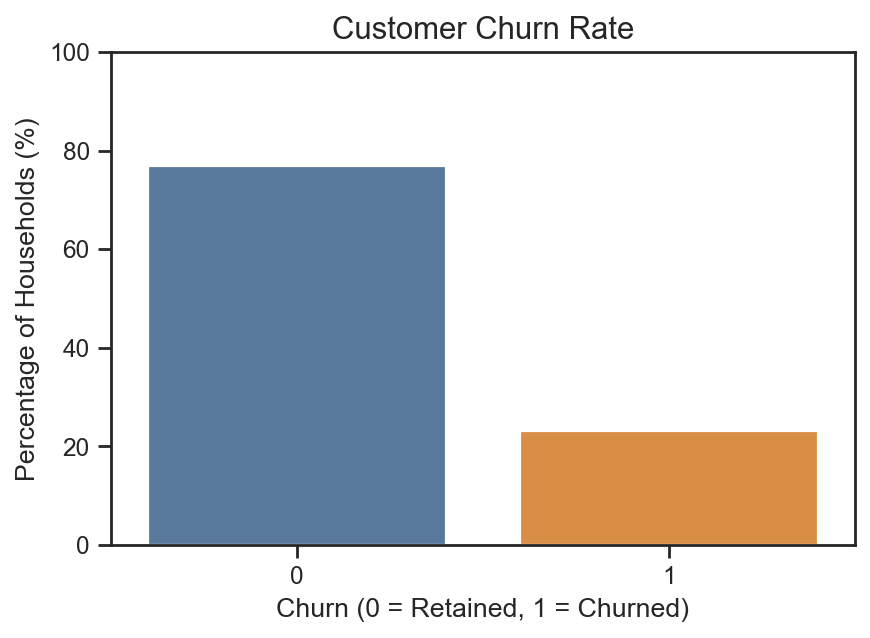

In [90]:
eda.plot_churn_rate(churn_train, colours)

## Demographics

In [61]:
demographics_train, demographics_valid, demographics_test = eda.clean_demographics(eda.demographics)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1469307 entries, 0 to 1469306
Data columns (total 11 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   household_id           1469307 non-null  int64         
 1   store_id               1469307 non-null  int64         
 2   basket_id              1469307 non-null  int64         
 3   product_id             1469307 non-null  int64         
 4   quantity               1469307 non-null  int64         
 5   sales_value            1469307 non-null  float64       
 6   retail_disc            1469307 non-null  float64       
 7   coupon_disc            1469307 non-null  float64       
 8   coupon_match_disc      1469307 non-null  float64       
 9   week                   1469307 non-null  int64         
 10  transaction_timestamp  1469307 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(4), int64(6)
memory usage: 123.3 MB
Missing values in trans

### Demographics Data Cleaning

Considering the amount of missing values in home_ownership and marital status, and the fact that they most likely don't have much informative data on customer churn, we remove these columns from the dataset. 

In [71]:
print(demographics_train.head())
print(demographics_valid.head())
print(demographics_test.head())
print(f"Training datapoints: {demographics_train.shape[0]}")
print(f"Validation datapoints: {demographics_valid.shape[0]}")
print(f"Test datapoints: {demographics_test.shape[0]}")

   household_id    age     income household_size    household_comp kids_count
0             1    65+     35-49K              2  2 Adults No Kids          0
1          1001  45-54     50-74K              1   1 Adult No Kids          0
2          1003  35-44     25-34K              1   1 Adult No Kids          0
3          1004  25-34     15-24K              1   1 Adult No Kids          0
4           101  45-54  Under 15K              4     2 Adults Kids          2
    household_id    age     income household_size    household_comp kids_count
11          1024  25-34  Under 15K              4     2 Adults Kids          2
26          1070  35-44     50-74K              2  2 Adults No Kids          0
41           113  35-44   125-149K              4     2 Adults Kids          2
44          1135  45-54     50-74K              2      1 Adult Kids          1
45          1137    65+     35-49K              1   1 Adult No Kids          0
    household_id    age    income household_size    househ

### Demographics Visualisation

## Transactions

In [9]:
transactions_train, transactions_valid, transactions_test = eda.clean_transactions(eda.transactions)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1469307 entries, 0 to 1469306
Data columns (total 11 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   household_id           1469307 non-null  int64         
 1   store_id               1469307 non-null  int64         
 2   basket_id              1469307 non-null  int64         
 3   product_id             1469307 non-null  int64         
 4   quantity               1469307 non-null  int64         
 5   sales_value            1469307 non-null  float64       
 6   retail_disc            1469307 non-null  float64       
 7   coupon_disc            1469307 non-null  float64       
 8   coupon_match_disc      1469307 non-null  float64       
 9   week                   1469307 non-null  int64         
 10  transaction_timestamp  1469307 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(4), int64(6)
memory usage: 123.3 MB
Number of duplicate row